In [ ]:
!pip install langchain
!pip install langchain_openai
import os
os.environ['OPENAI_API_KEY'] = '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'
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI

llm = ChatOpenAI()

In [ ]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [ ]:
def chat_node(state: ChatState):

    # take user query from state
    messages = state['messages']

    # send to llm
    response = llm.invoke(messages)

    # response store state
    return {'messages': [response]}

In [ ]:
graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile()


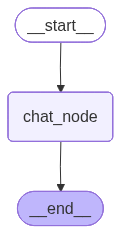

In [ ]:
chatbot

# A LangGraph chatbot is an AI chatbot built using LangGraph, where the conversation is modeled as a graph (nodes + edges) instead of a simple linear chain.

# Unlike a basic chatbot that just takes input → generates output, a LangGraph chatbot can:

Remember conversation state

Make decisions

Call tools

Use RAG

Ask for clarification

Retry failed steps

Support human approval

Run multiple tasks in parallel